# 🎯 Обучение модели локализации паттерна "Голова и Плечи"

Оптимизированный ноутбук для обучения CNN-LSTM модели с предсказанием координат паттернов

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import warnings
import seaborn as sns
import random

try:
    import yfinance as yf
except ImportError:
    import sys
    !{sys.executable} -m pip install yfinance
    import yfinance as yf

from model_architecture import CNNLSTMLocalizationModel

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# === КОНФИГУРАЦИЯ ===
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
WINDOW_SIZE = 120
BATCH_SIZE = 32
EPOCHS = 150
PATIENCE = 20
LEARNING_RATE = 0.0015
VAL_SPLIT = 0.2
LAMBDA_LOC = 1.0  # Вес локализации
LAMBDA_ORDER = 0.1  # Штраф за нарушение start <= end

print(f"Устройство: {DEVICE}")
print(f"Параметры: EPOCHS={EPOCHS}, LR={LEARNING_RATE}, LAMBDA_LOC={LAMBDA_LOC}")


Устройство: cpu
Параметры: EPOCHS=150, LR=0.0015, LAMBDA_LOC=1.0


## 1. Загрузка и подготовка данных

In [22]:
# Загрузка данных
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

feature_cols = [col for col in train_df.columns if col.startswith('t')]

X_train = train_df[feature_cols].values.astype(np.float32)
y_train = train_df['has_pattern'].values.astype(np.float32)
start_train = train_df['pattern_start'].values.astype(np.float32)
end_train = train_df['pattern_end'].values.astype(np.float32)

X_test = test_df[feature_cols].values.astype(np.float32)
y_test = test_df['has_pattern'].values.astype(np.float32)
start_test = test_df['pattern_start'].values.astype(np.float32)
end_test = test_df['pattern_end'].values.astype(np.float32)

# Аугментация обучающего набора
def augment_data(X, y, start, end, factor=2, noise=0.015):
    X_aug, y_aug, s_aug, e_aug = [X], [y], [start], [end]
    for i in range(factor):
        aug_type = i % 4
        if aug_type == 0:
            X_new = X + np.random.normal(0, noise, X.shape)
        elif aug_type == 1:
            X_new = X * np.random.uniform(0.95, 1.05, (1,))
        elif aug_type == 2:
            X_new = X + np.random.normal(0, noise * 0.5, X.shape)
        else:
            X_new = X * np.random.uniform(0.97, 1.03) + np.random.normal(0, noise * 0.7, X.shape)
        X_aug.append(np.clip(X_new, -5, 5))
        y_aug.append(y)
        s_aug.append(start)
        e_aug.append(end)
    return np.vstack(X_aug), np.concatenate(y_aug), np.concatenate(s_aug), np.concatenate(e_aug)

X_train, y_train, start_train, end_train = augment_data(X_train, y_train, start_train, end_train, factor=2, noise=0.015)

# Преобразование для Conv1D (batch, channels, timesteps)
X_train = X_train.reshape(-1, 1, X_train.shape[1])
X_test = X_test.reshape(-1, 1, X_test.shape[1])

print(f"✓ Обучение: {X_train.shape[0]} образцов | Тестирование: {X_test.shape[0]} образцов")
print(f"✓ Классы обучения: {(y_train==1).sum()} с паттерном, {(y_train==0).sum()} без")

✓ Обучение: 1440 образцов | Тестирование: 120 образцов
✓ Классы обучения: 720 с паттерном, 720 без


## 2. Подготовка тензоров и DataLoader'ов

In [23]:
# Преобразование в тензоры
X_train_t = torch.FloatTensor(X_train).to(DEVICE)
y_train_t = torch.FloatTensor(y_train).to(DEVICE)
start_train_t = torch.FloatTensor(start_train).to(DEVICE)
end_train_t = torch.FloatTensor(end_train).to(DEVICE)

X_test_t = torch.FloatTensor(X_test).to(DEVICE)

# Разделение обучения/валидации
np.random.seed(42)
val_size = int(len(X_train_t) * VAL_SPLIT)
val_idx = np.random.choice(len(X_train_t), val_size, replace=False)
train_idx = np.array([i for i in range(len(X_train_t)) if i not in val_idx])

X_val = X_train_t[val_idx]
y_val = y_train_t[val_idx]
start_val = start_train_t[val_idx]
end_val = end_train_t[val_idx]

# Для визуализации
X_val_np = X_val.cpu().numpy()
y_val_np = y_val.cpu().numpy()
start_val_np = start_val.cpu().numpy()
end_val_np = end_val.cpu().numpy()

# DataLoader
train_dataset = TensorDataset(
    X_train_t[train_idx], y_train_t[train_idx],
    start_train_t[train_idx], end_train_t[train_idx]
)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f"✓ Обучение: {len(train_idx)}, Валидация: {len(val_idx)}, Тестирование: {X_test_t.shape[0]}")

✓ Обучение: 1152, Валидация: 288, Тестирование: 120


## 3. Функции обучения и валидации

In [24]:
def train_epoch(model, loader, opt, crit_cls, crit_loc, lambda_loc, lambda_order, device):
    model.train()
    total_loss = cls_loss = loc_loss = order_loss = correct = total = 0.0
    
    for X_b, y_b, s_b, e_b in loader:
        opt.zero_grad()
        cls_p, s_p, e_p = model(X_b)
        
        loss_c = crit_cls(cls_p, y_b.view(-1, 1))
        mask = y_b.view(-1, 1) > 0.5
        
        if mask.sum() > 0:
            loss_l = crit_loc(s_p[mask], s_b.view(-1, 1)[mask]) + \
                     crit_loc(e_p[mask], e_b.view(-1, 1)[mask])
            loss_o = torch.clamp(s_p[mask] - e_p[mask], min=0).mean()
        else:
            loss_l = loss_o = torch.tensor(0.0, device=device)
        
        loss = loss_c + lambda_loc * loss_l + lambda_order * loss_o
        loss.backward()
        opt.step()
        
        total_loss += loss.item()
        cls_loss += loss_c.item()
        if mask.sum() > 0:
            loc_loss += loss_l.item()
            order_loss += loss_o.item()
        correct += ((cls_p > 0.5).float() == y_b.view(-1, 1)).sum().item()
        total += y_b.size(0)
    
    return total_loss/len(loader), cls_loss/len(loader), loc_loss/len(loader), order_loss/len(loader), correct/total

def validate(model, X_v, y_v, s_v, e_v, crit_cls, crit_loc, lambda_loc, lambda_order, device):
    model.eval()
    with torch.no_grad():
        cls_p, s_p, e_p = model(X_v)
        loss_c = crit_cls(cls_p, y_v.view(-1, 1))
        mask = y_v.view(-1, 1) > 0.5
        
        if mask.sum() > 0:
            loss_l = crit_loc(s_p[mask], s_v.view(-1, 1)[mask]) + \
                     crit_loc(e_p[mask], e_v.view(-1, 1)[mask])
            loss_o = torch.clamp(s_p[mask] - e_p[mask], min=0).mean()
        else:
            loss_l = loss_o = torch.tensor(0.0, device=device)
        
        total_loss = loss_c + lambda_loc * loss_l + lambda_order * loss_o
        correct = ((cls_p > 0.5).float() == y_v.view(-1, 1)).sum().item()
    
    return total_loss.item(), loss_c.item(), loss_l.item() if loss_l > 0 else 0, correct/y_v.size(0)

print("✓ Функции обучения и валидации определены")

✓ Функции обучения и валидации определены


## 4. Обучение модели

In [25]:
model = CNNLSTMLocalizationModel().to(DEVICE)
params = sum(p.numel() for p in model.parameters())
print(f"🔧 Модель: {params:,} параметров\n")

opt = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
crit_cls = nn.BCELoss()
crit_loc = nn.MSELoss()

best_loss = float('inf')
patience_cnt = 0
hist = {'loss': [], 'val_loss': [], 'acc': [], 'val_acc': []}

print(f"{'Эпоха':<6} {'Обуч. Loss':<14} {'Вал. Loss':<14} {'Обуч. Acc':<12} {'Вал. Acc':<12}")
print("-" * 70)

for epoch in range(EPOCHS):
    loss, _, _, _, acc = train_epoch(model, train_loader, opt, crit_cls, crit_loc, LAMBDA_LOC, LAMBDA_ORDER, DEVICE)
    val_loss, _, _, val_acc = validate(model, X_val, y_val, start_val, end_val, crit_cls, crit_loc, LAMBDA_LOC, LAMBDA_ORDER, DEVICE)
    
    hist['loss'].append(loss)
    hist['val_loss'].append(val_loss)
    hist['acc'].append(acc)
    hist['val_acc'].append(val_acc)
    
    if val_loss < best_loss:
        best_loss = val_loss
        patience_cnt = 0
        torch.save(model.state_dict(), 'best_model_loc.pt')
        status = "✓"
    else:
        patience_cnt += 1
        status = ""
    
    if (epoch + 1) % 10 == 0 or epoch == 0 or patience_cnt >= PATIENCE:
        print(f"{epoch+1:<6} {loss:<14.4f} {val_loss:<14.4f} {acc:<12.4f} {val_acc:<12.4f} {status}")
    
    if patience_cnt >= PATIENCE:
        print(f"\n⚠ Остановка на эпохе {epoch + 1}")
        break

model.load_state_dict(torch.load('best_model_loc.pt'))
print(f"\n✓ Обучение завершено ({len(hist['loss'])} эпох)")

🔧 Модель: 462,371 параметров

Эпоха  Обуч. Loss     Вал. Loss      Обуч. Acc    Вал. Acc    
----------------------------------------------------------------------
1      0.4095         0.1183         0.8993       1.0000       ✓
10     0.0076         0.0044         1.0000       1.0000       
20     0.0208         0.0089         0.9991       1.0000       
30     0.0049         0.0014         1.0000       1.0000       ✓
40     0.0039         0.0019         1.0000       1.0000       
50     0.0170         0.0107         0.9991       1.0000       
60     0.0075         0.0040         0.9991       1.0000       
61     0.0053         0.0029         1.0000       1.0000       

⚠ Остановка на эпохе 61

✓ Обучение завершено (61 эпох)


## 5. Визуализация обучения

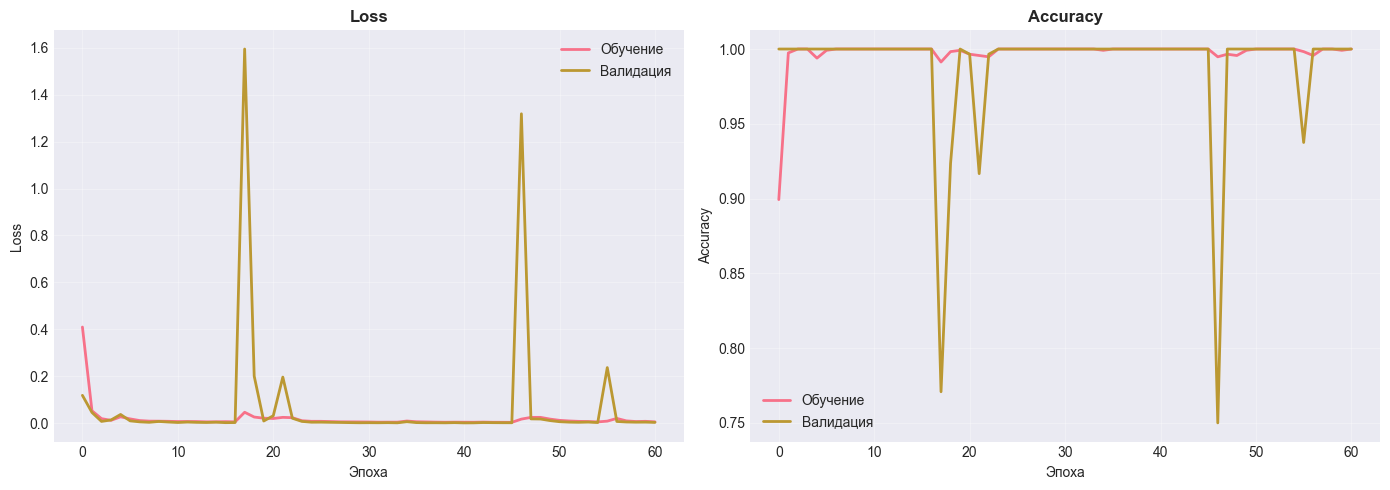

✓ История обучения сохранена


In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(hist['loss'], label='Обучение', linewidth=2)
ax1.plot(hist['val_loss'], label='Валидация', linewidth=2)
ax1.set_title('Loss', fontsize=12, fontweight='bold')
ax1.set_xlabel('Эпоха')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(hist['acc'], label='Обучение', linewidth=2)
ax2.plot(hist['val_acc'], label='Валидация', linewidth=2)
ax2.set_title('Accuracy', fontsize=12, fontweight='bold')
ax2.set_xlabel('Эпоха')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ История обучения сохранена")

## 6. Проверка на валидационной выборке

In [27]:
model.eval()
with torch.no_grad():
    cls_p, s_p, e_p = model(X_val)
    cls_np = cls_p.squeeze().cpu().numpy()
    s_np = s_p.squeeze().cpu().numpy()
    e_np = e_p.squeeze().cpu().numpy()

s_idx = (s_np * WINDOW_SIZE).astype(int)
e_idx = (e_np * WINDOW_SIZE).astype(int)
s_act = (start_val_np * WINDOW_SIZE).astype(int)
e_act = (end_val_np * WINDOW_SIZE).astype(int)

y_pred = (cls_np > 0.5).astype(int)
acc = accuracy_score(y_val_np, y_pred)
prec = precision_score(y_val_np, y_pred, zero_division=0)
rec = recall_score(y_val_np, y_pred, zero_division=0)
f1 = f1_score(y_val_np, y_pred, zero_division=0)
auc = roc_auc_score(y_val_np, cls_np)

print(f"\n📊 МЕТРИКИ ВАЛИДАЦИИ")
print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")

mask = y_val_np == 1
if mask.sum() > 0:
    s_err = np.abs(s_idx[mask] - s_act[mask])
    e_err = np.abs(e_idx[mask] - e_act[mask])
    print(f"\nЛокализация ({mask.sum()} с паттерном):")
    print(f"  Начало: {s_err.mean():.2f}±{s_err.std():.2f} | Конец: {e_err.mean():.2f}±{e_err.std():.2f} индексов")


📊 МЕТРИКИ ВАЛИДАЦИИ
Accuracy: 1.0000 | Precision: 1.0000 | Recall: 1.0000 | F1: 1.0000 | AUC: 1.0000

Локализация (148 с паттерном):
  Начало: 1.93±1.61 | Конец: 1.77±1.74 индексов


## 7. Визуализация примеров

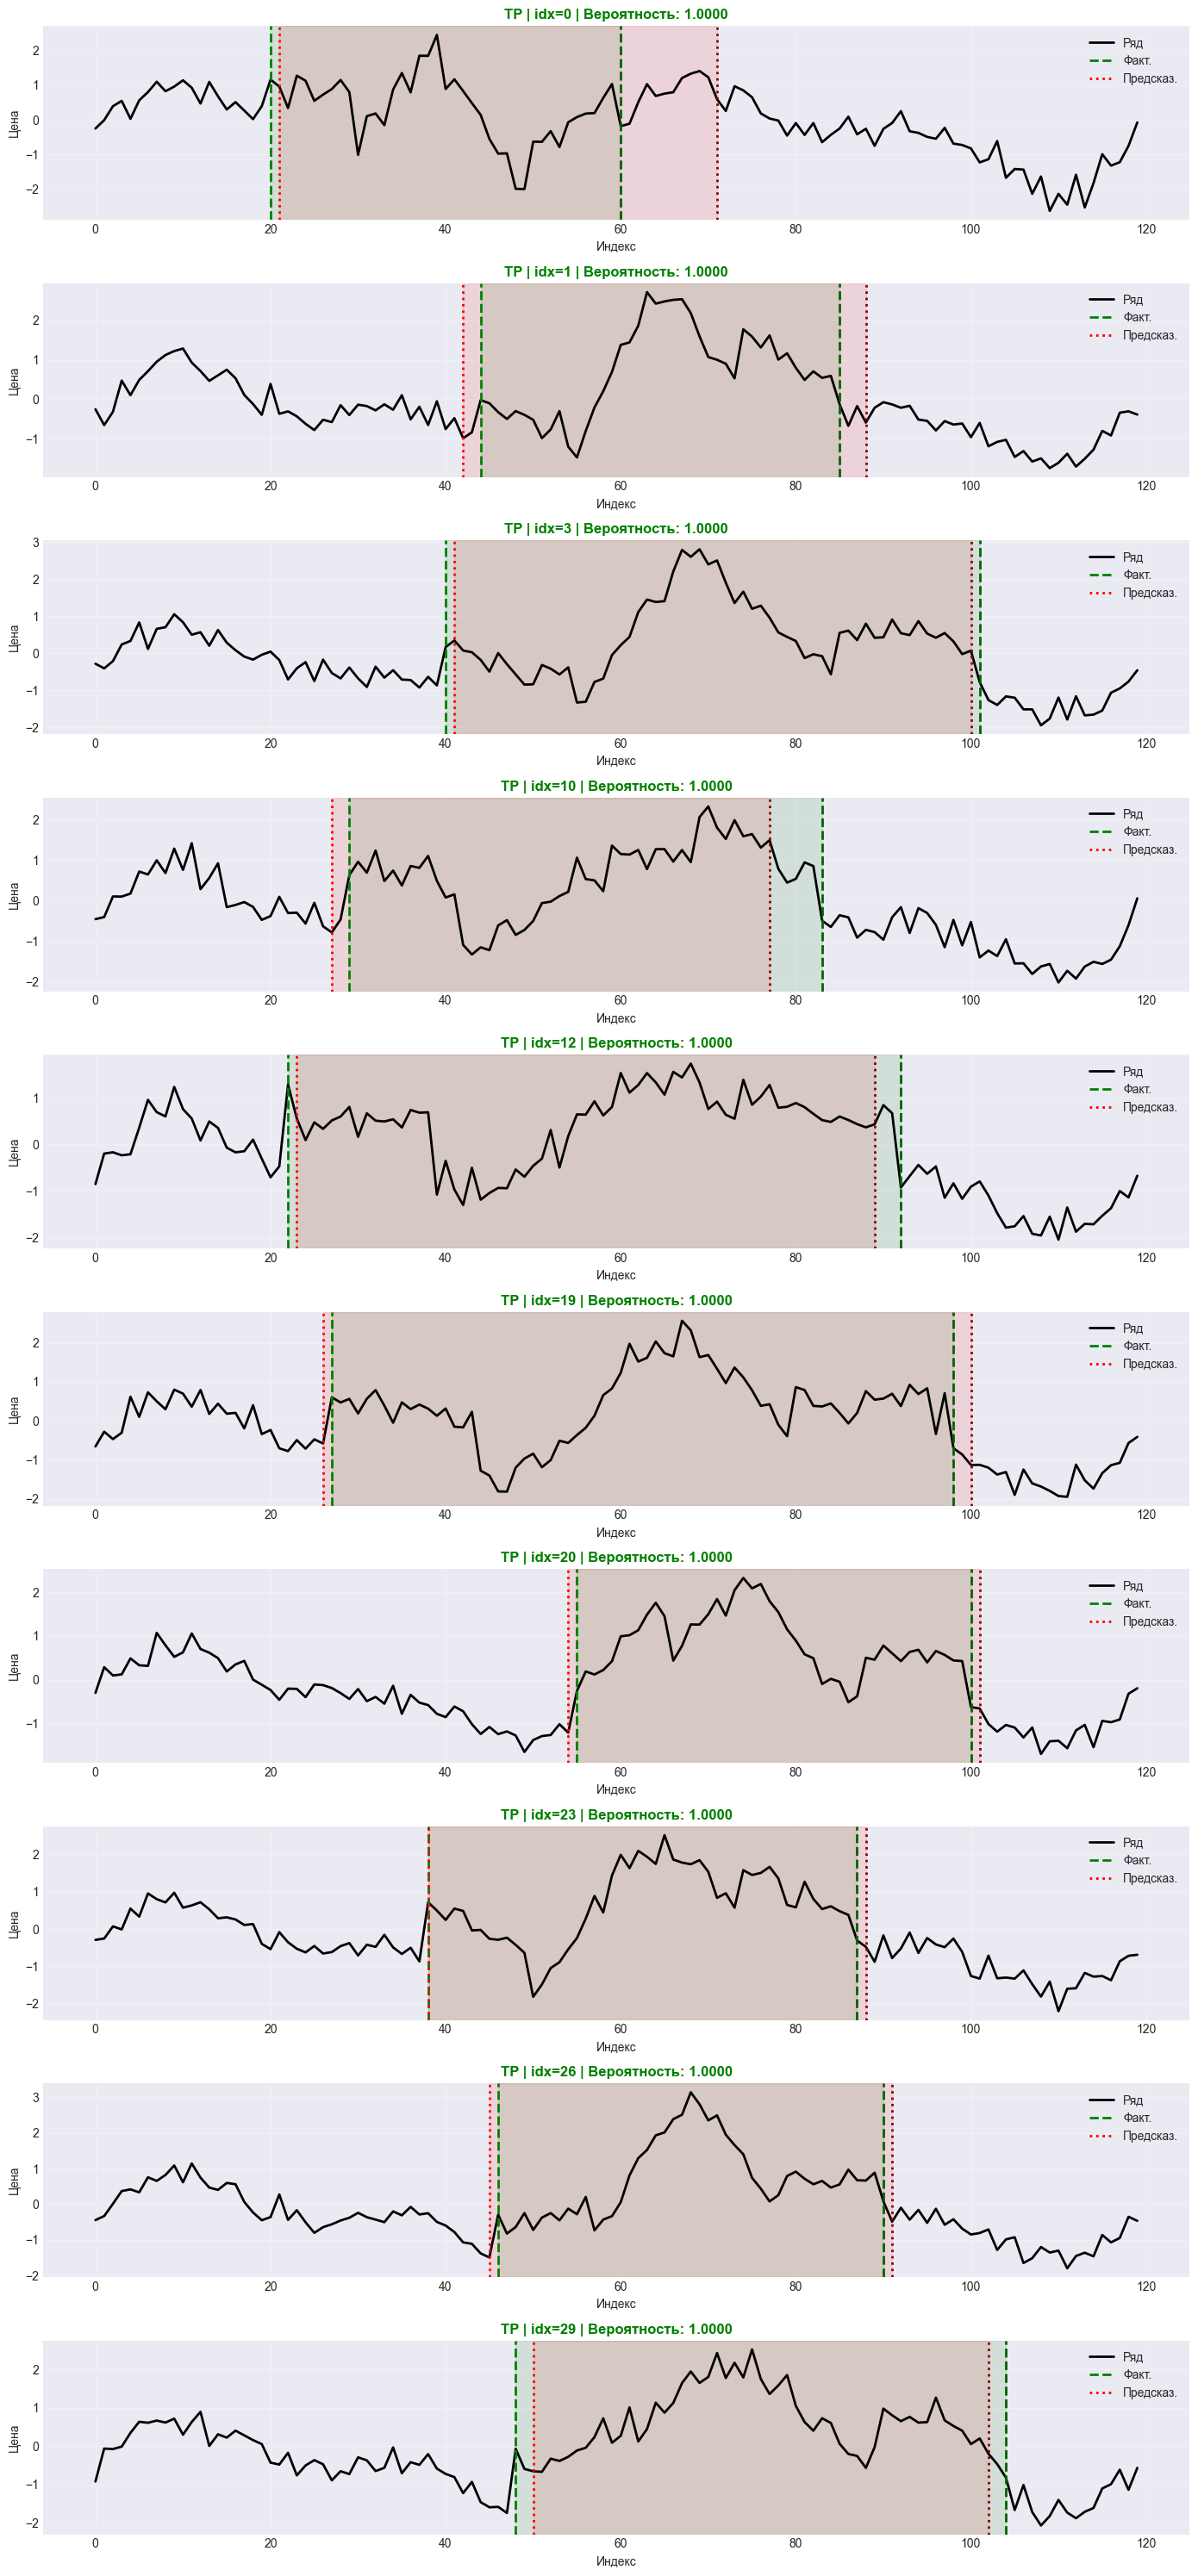

✓ Отображено 10 TP примеров


In [38]:
# Находим индексы TP
tp = np.where((y_val_np == 1) & (y_pred == 1))[0]

# Берем первые 10 (или меньше, если их недостаточно)
tp_samples = tp[:10]

fig, axes = plt.subplots(len(tp_samples), 1, figsize=(14, 3 * len(tp_samples)))

# Если только один график — оборачиваем в список
if len(tp_samples) == 1:
    axes = [axes]

for idx, ax in zip(tp_samples, axes):
    ts = X_val_np[idx, 0, :]
    
    # Рисуем временной ряд
    ax.plot(range(WINDOW_SIZE), ts, 'k-', linewidth=2, label='Ряд')
    
    # Фактический интервал (всегда есть, т.к. TP)
    ax.axvline(s_act[idx], color='green', linestyle='--', linewidth=2, label='Факт.')
    ax.axvline(e_act[idx], color='darkgreen', linestyle='--', linewidth=2)
    ax.axvspan(s_act[idx], e_act[idx], alpha=0.1, color='green')
    
    # Предсказанный интервал
    ax.axvline(s_idx[idx], color='red', linestyle=':', linewidth=2, label='Предсказ.')
    ax.axvline(e_idx[idx], color='darkred', linestyle=':', linewidth=2)
    ax.axvspan(s_idx[idx], e_idx[idx], alpha=0.1, color='red')
    
    ax.set_title(f"TP | idx={idx} | Вероятность: {cls_np[idx]:.4f}",
                 fontsize=12, fontweight='bold', color='green')
    ax.set_xlabel('Индекс')
    ax.set_ylabel('Цена')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('tp_examples.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Отображено {len(tp_samples)} TP примеров")

## 8. Проверка на тестовом наборе

In [29]:
with torch.no_grad():
    cls_test, s_test, e_test = model(X_test_t)
    cls_test_np = cls_test.squeeze().cpu().numpy()
    s_test_np = s_test.squeeze().cpu().numpy()
    e_test_np = e_test.squeeze().cpu().numpy()

s_test_idx = (s_test_np * WINDOW_SIZE).astype(int)
e_test_idx = (e_test_np * WINDOW_SIZE).astype(int)
s_test_act = (start_test * WINDOW_SIZE).astype(int)
e_test_act = (end_test * WINDOW_SIZE).astype(int)

y_test_pred = (cls_test_np > 0.5).astype(int)
test_acc = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred, zero_division=0)
test_auc = roc_auc_score(y_test, cls_test_np)

print(f"\n📊 МЕТРИКИ ТЕСТИРОВАНИЯ")
print(f"Accuracy: {test_acc:.4f} | F1: {test_f1:.4f} | AUC: {test_auc:.4f}")

mask_t = y_test == 1
if mask_t.sum() > 0:
    s_err_t = np.abs(s_test_idx[mask_t] - s_test_act[mask_t])
    e_err_t = np.abs(e_test_idx[mask_t] - e_test_act[mask_t])
    print(f"\nЛокализация: Начало {s_err_t.mean():.2f}±{s_err_t.std():.2f} | Конец {e_err_t.mean():.2f}±{e_err_t.std():.2f}")


📊 МЕТРИКИ ТЕСТИРОВАНИЯ
Accuracy: 0.9917 | F1: 0.9916 | AUC: 1.0000

Локализация: Начало 2.65±2.20 | Конец 1.75±2.01


## 9. Проверка на реальном случайном ряде из yfinance

In [31]:
def load_random_yfinance_window(window_size=WINDOW_SIZE, tickers=None, period='1y', interval='1d'):
    if tickers is None:
        tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'NVDA', 'META', 'JPM', 'V', 'PG']
    ticker = np.random.choice(tickers)
    df = yf.download(ticker, period=period, interval=interval, progress=False)
    close = df['Close'].dropna()
    if len(close) < window_size:
        raise ValueError(f"Не удалось получить {window_size} точек для {ticker}, получено {len(close)}")

    start_idx = np.random.randint(0, len(close) - window_size + 1)
    window = close.iloc[start_idx:start_idx + window_size].astype(np.float32).values
    normalized = (window - window.mean()) / (window.std() + 1e-8)
    return ticker, normalized, window

print('Загрузка случайного реального ряда из yfinance...')
ticker, real_window, real_series = load_random_yfinance_window()
print(f'Выбран тикер: {ticker}, длина окна: {len(real_window)}')

X_real = torch.FloatTensor(real_window.reshape(1, 1, -1)).to(DEVICE)
model.eval()
with torch.no_grad():
    cls_real, s_real, e_real = model(X_real)

cls_real = float(cls_real.item())
s_real = float(s_real.item())
e_real = float(e_real.item())

s_idx_real = int(np.clip(s_real * WINDOW_SIZE, 0, WINDOW_SIZE - 1))
e_idx_real = int(np.clip(e_real * WINDOW_SIZE, 0, WINDOW_SIZE - 1))

print(f"\nРеальная последовательность {ticker}:")
print(f"  Вероятность паттерна: {cls_real:.4f}")
print(f"  Предсказанное начало: {s_idx_real}, конец: {e_idx_real}")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(range(WINDOW_SIZE), real_series, color='black', linewidth=2, label='Real Close')
ax.axvline(s_idx_real, color='red', linestyle='--', linewidth=2, label='Predicted Start')
ax.axvline(e_idx_real, color='blue', linestyle='--', linewidth=2, label='Predicted End')
if s_idx_real < e_idx_real:
    ax.axvspan(s_idx_real, e_idx_real, alpha=0.15, color='red')
ax.set_title(f'Real series {ticker} | P(pattern)={cls_real:.4f}')
ax.set_xlabel('Index')
ax.set_ylabel('Close Price')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print('✓ Оценка реального ряда завершена')


Загрузка случайного реального ряда из yfinance...


Failed to get ticker 'AMZN' reason: Failed to perform, curl: (77) error setting certificate verify locations:  CAfile: c:\Users\rtsoli\проектики\диплом\.venv\Lib\site-packages\certifi\cacert.pem CApath: none. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.

1 Failed download:
['AMZN']: SSLError('Failed to perform, curl: (77) error setting certificate verify locations:  CAfile: c:\\Users\\rtsoli\\проектики\\диплом\\.venv\\Lib\\site-packages\\certifi\\cacert.pem CApath: none. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.')


ValueError: Не удалось получить 120 точек для AMZN, получено 0